# 06 -- Cross-Border Flow Analysis

The Nordic-Continental electricity market is split into bidding zones connected by
HVDC cables and AC tie-lines. When interconnector capacity is sufficient, adjacent
zones converge to the same price. When a line is congested, prices diverge --
the spread reflects the scarcity of transmission capacity.

This notebook maps the interconnectors around Denmark and analyses price relationships
between adjacent bidding zones.

**Key interconnectors:**

| From | To | Capacity (MW) | Notes |
|------|-----|--------------|-------|
| DK1 | DE-LU | 2,500 | Jutland--Germany AC lines |
| DK1 | NO2 | 1,700 | Skagerrak HVDC cables |
| DK1 | SE3 | 740 | AC tie-line |
| DK1 | DK2 | 600 | Great Belt HVDC link |
| DK2 | DE-LU | 600 | Kontek HVDC cable |
| DK2 | SE4 | 1,700 | AC interconnection |

Adjacent zones with sufficient data represent expansion opportunities for the
forecasting model.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx

from da_forecast.config import INTERCONNECTORS, ZONES, ZONE_LABELS
from da_forecast.data import load_prices

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Interconnector Table

In [2]:
ic_df = pd.DataFrame(INTERCONNECTORS, columns=["from_zone", "to_zone", "capacity_mw"])
ic_df["from_label"] = ic_df["from_zone"].map(ZONE_LABELS)
ic_df["to_label"] = ic_df["to_zone"].map(ZONE_LABELS)
display(ic_df[["from_zone", "from_label", "to_zone", "to_label", "capacity_mw"]])

,from_zone,from_label,to_zone,to_label,capacity_mw
0,DK_1,West Denmark,DE_LU,Germany-Luxembourg,2500
1,DK_1,West Denmark,NO_2,South Norway,1700
2,DK_1,West Denmark,SE_3,Central Sweden,740
3,DK_2,East Denmark,DE_LU,Germany-Luxembourg,600
4,DK_2,East Denmark,SE_4,South Sweden,1700
5,DK_1,West Denmark,DK_2,East Denmark,600


## 2. Network Graph

Geographic layout with edge width proportional to interconnector capacity.

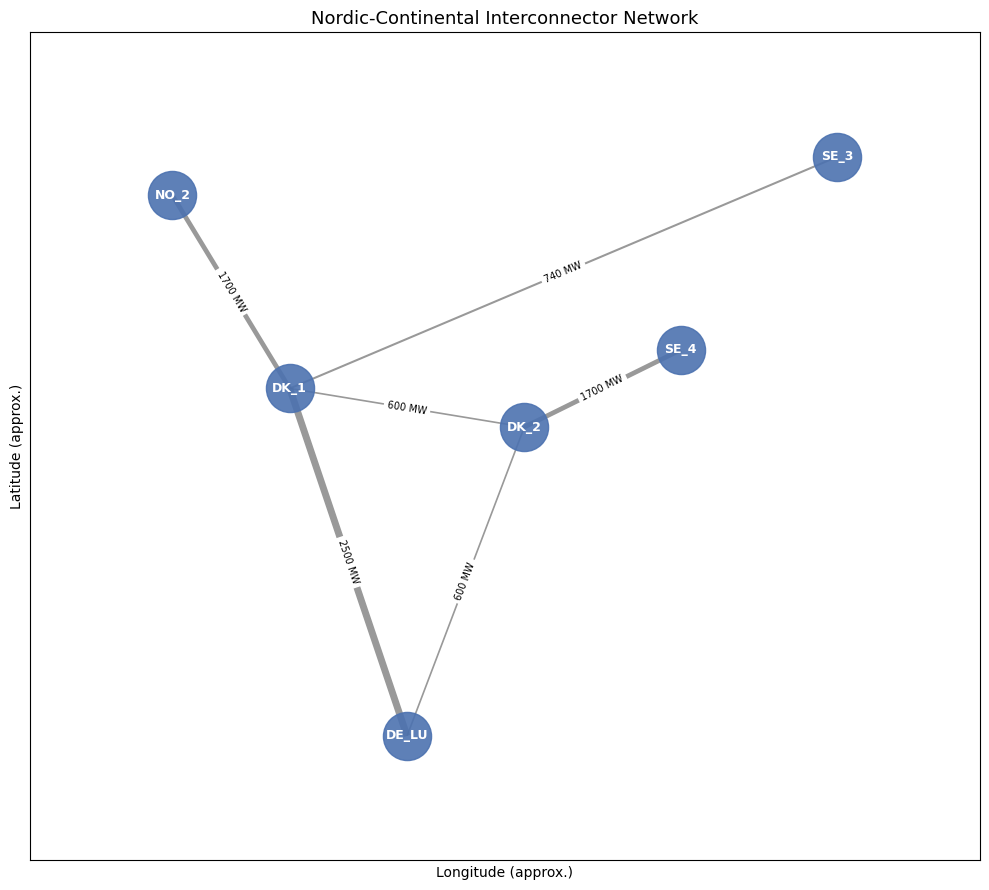

In [3]:
# Approximate geographic positions (longitude, latitude) for layout
zone_positions = {
    "DK_1": (9.0, 56.0),   # Jutland
    "DK_2": (12.0, 55.5),  # Zealand
    "NO_2": (7.5, 58.5),   # Southern Norway
    "SE_3": (16.0, 59.0),  # Central Sweden
    "SE_4": (14.0, 56.5),  # Southern Sweden
    "DE_LU": (10.5, 51.5), # Germany
}

G = nx.Graph()
for zone in ZONES:
    G.add_node(zone, label=ZONE_LABELS.get(zone, zone))

for from_z, to_z, cap in INTERCONNECTORS:
    G.add_edge(from_z, to_z, capacity=cap)

fig, ax = plt.subplots(figsize=(10, 9))

pos = zone_positions
edge_widths = [G[u][v]["capacity"] / 500 for u, v in G.edges()]
edge_labels = {(u, v): f"{G[u][v]['capacity']} MW" for u, v in G.edges()}

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#4C72B0", alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color="#555555", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_color="white", ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)

ax.set_title("Nordic-Continental Interconnector Network", fontsize=13)
ax.set_xlabel("Longitude (approx.)")
ax.set_ylabel("Latitude (approx.)")
ax.margins(0.15)
plt.tight_layout()
plt.show()

## 3. Load All Zone Prices

In [4]:
zone_prices = {}
for zone in ZONES:
    try:
        df = load_prices(zone)
        zone_prices[zone] = df["price_eur_mwh"]
    except FileNotFoundError:
        print(f"  {zone}: no data available")

# Align to common index
all_prices = pd.DataFrame(zone_prices)
all_prices = all_prices.dropna(how="all")
print(f"\nAligned price matrix: {all_prices.shape[0]} hours x {all_prices.shape[1]} zones")
print(f"Date range: {all_prices.index.min()} -> {all_prices.index.max()}")
print(f"\nMissing values per zone:")
print(all_prices.isna().sum())

Loaded DK_1 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Loaded DK_2 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Loaded NO_2 prices from 'entsoe': 5137 hours (2025-03-01 -> 2025-10-01)
Loaded SE_3 prices from 'entsoe': 5137 hours (2025-03-01 -> 2025-10-01)
Loaded SE_4 prices from 'entsoe': 5137 hours (2025-03-01 -> 2025-10-01)
Loaded DE_LU prices from 'entsoe': 5136 hours (2025-03-01 -> 2025-10-01)

Aligned price matrix: 8760 hours x 6 zones
Date range: 2024-10-01 00:00:00+00:00 -> 2025-09-30 23:00:00+00:00

Missing values per zone:
DK_1        2
DK_2        2
NO_2     3623
SE_3     3623
SE_4     3623
DE_LU    3624
dtype: int64


## 4. Multi-Zone Price Comparison

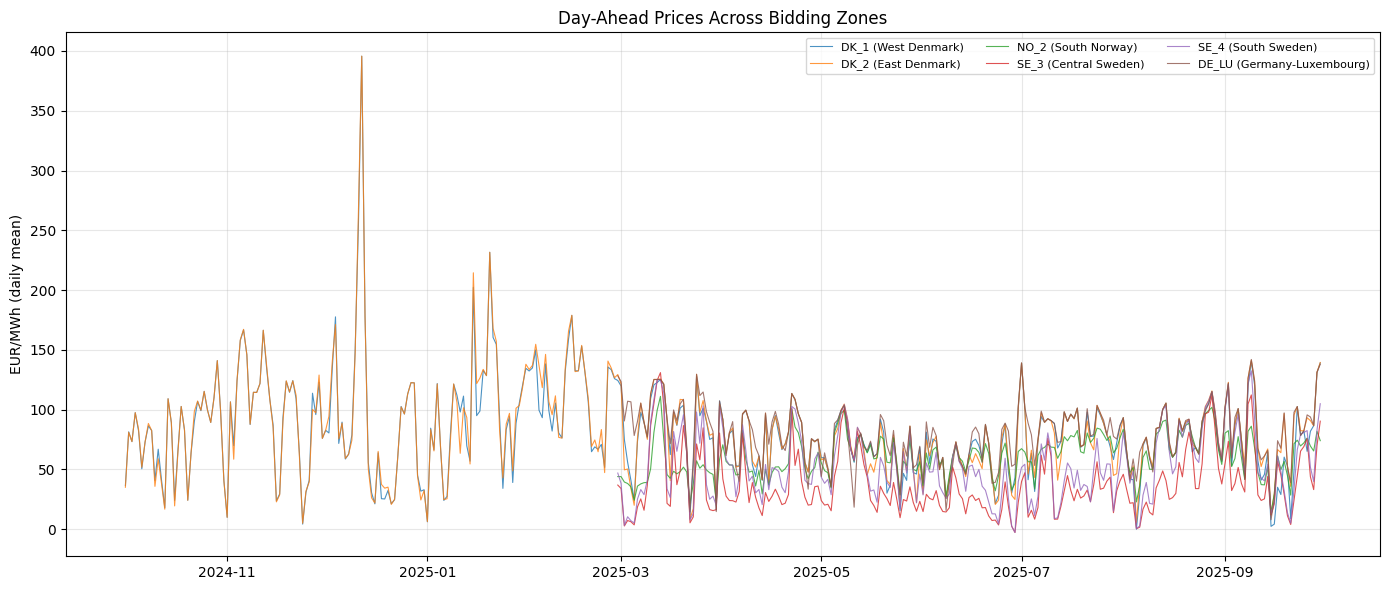

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
for i, zone in enumerate(all_prices.columns):
    # Plot daily mean for readability
    daily = all_prices[zone].resample("D").mean()
    ax.plot(daily.index, daily.values, linewidth=0.8, label=f"{zone} ({ZONE_LABELS.get(zone, '')})",
            color=colors[i % len(colors)], alpha=0.8)

ax.set_ylabel("EUR/MWh (daily mean)")
ax.set_title("Day-Ahead Prices Across Bidding Zones")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pairwise Price Correlations

High correlation between adjacent zones indicates the interconnector is rarely
congested. Low correlation suggests frequent bottlenecks.

In [6]:
# Only compute correlations for adjacent zones (connected by an interconnector)
adjacent_pairs = [(f, t) for f, t, _ in INTERCONNECTORS]

corr_data = []
for z1, z2 in adjacent_pairs:
    if z1 in all_prices.columns and z2 in all_prices.columns:
        pair = all_prices[[z1, z2]].dropna()
        if len(pair) > 100:
            r = pair[z1].corr(pair[z2])
            corr_data.append({"zone_1": z1, "zone_2": z2, "correlation": r, "n_hours": len(pair)})

corr_df = pd.DataFrame(corr_data).sort_values("correlation", ascending=False)
display(corr_df)

,zone_1,zone_2,correlation,n_hours
5,DK_1,DK_2,0.967900,8758
0,DK_1,DE_LU,0.922003,5135
3,DK_2,DE_LU,0.917791,5135
4,DK_2,SE_4,0.797553,5135
1,DK_1,NO_2,0.712280,5135
2,DK_1,SE_3,0.683644,5135


## 6. Spread Analysis

The price spread between two zones is the direct measure of congestion rent.
When the spread is zero, the interconnector has spare capacity. Persistent
non-zero spreads indicate structural congestion.

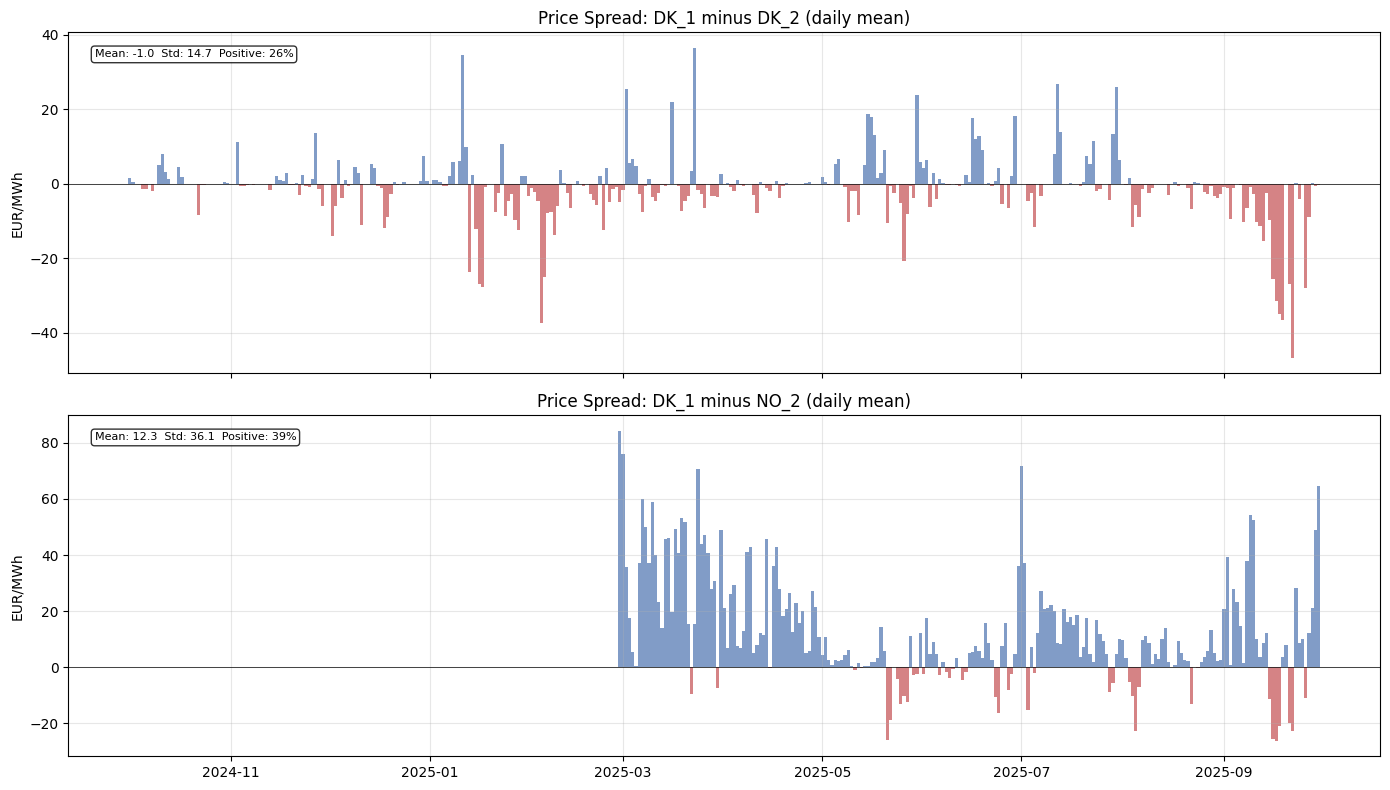

In [7]:
spread_pairs = [("DK_1", "DK_2"), ("DK_1", "NO_2")]

fig, axes = plt.subplots(len(spread_pairs), 1, figsize=(14, 4 * len(spread_pairs)), sharex=True)
if len(spread_pairs) == 1:
    axes = [axes]

for ax, (z1, z2) in zip(axes, spread_pairs):
    if z1 not in all_prices.columns or z2 not in all_prices.columns:
        ax.text(0.5, 0.5, f"Data not available for {z1} or {z2}", transform=ax.transAxes, ha="center")
        continue

    spread = all_prices[z1] - all_prices[z2]
    daily_spread = spread.resample("D").mean()

    ax.bar(daily_spread.index, daily_spread.values, width=1, alpha=0.7,
           color=np.where(daily_spread.values >= 0, "#4C72B0", "#C44E52"))
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_ylabel("EUR/MWh")
    ax.set_title(f"Price Spread: {z1} minus {z2} (daily mean)")
    ax.grid(True, alpha=0.3)

    # Summary stats
    mean_s = spread.mean()
    std_s = spread.std()
    pct_positive = (spread > 0).mean() * 100
    ax.text(0.02, 0.95, f"Mean: {mean_s:.1f}  Std: {std_s:.1f}  Positive: {pct_positive:.0f}%",
            transform=ax.transAxes, fontsize=8, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

## 7. Lagged Cross-Zone Correlations

Prices in adjacent zones may lead or lag each other due to interconnector flow
dynamics and different generation mixes. We compute correlation at lags 0--3h
between DK1 and each adjacent zone.

In [8]:
dk1_adjacent = [z for f, z, _ in INTERCONNECTORS if f == "DK_1"] + \
               [f for f, z, _ in INTERCONNECTORS if z == "DK_1"]
dk1_adjacent = sorted(set(dk1_adjacent))

lags = [0, 1, 2, 3]
lag_corr_data = []

dk1 = all_prices.get("DK_1")
if dk1 is not None:
    for zone in dk1_adjacent:
        if zone not in all_prices.columns:
            continue
        other = all_prices[zone]
        for lag in lags:
            shifted = other.shift(lag)
            pair = pd.concat([dk1, shifted], axis=1).dropna()
            if len(pair) > 100:
                r = pair.iloc[:, 0].corr(pair.iloc[:, 1])
                lag_corr_data.append({"zone": zone, "lag_hours": lag, "correlation": r})

lag_corr_df = pd.DataFrame(lag_corr_data)
if not lag_corr_df.empty:
    pivot = lag_corr_df.pivot(index="zone", columns="lag_hours", values="correlation")
    pivot.columns = [f"lag_{h}h" for h in pivot.columns]
    display(pivot.round(4))
else:
    print("Insufficient data for lagged correlation analysis.")

,lag_0h,lag_1h,lag_2h,lag_3h
zone,,,,
DE_LU,0.9220,0.8311,0.6486,0.4498
DK_2,0.9679,0.8980,0.7637,0.6234
NO_2,0.7123,0.6629,0.5602,0.4356
SE_3,0.6836,0.6287,0.5035,0.3698


## 8. Hourly Price Heatmaps by Zone

Average price by hour-of-day and month reveals structural patterns:
morning and evening peaks, seasonal variation, and differences across zones.

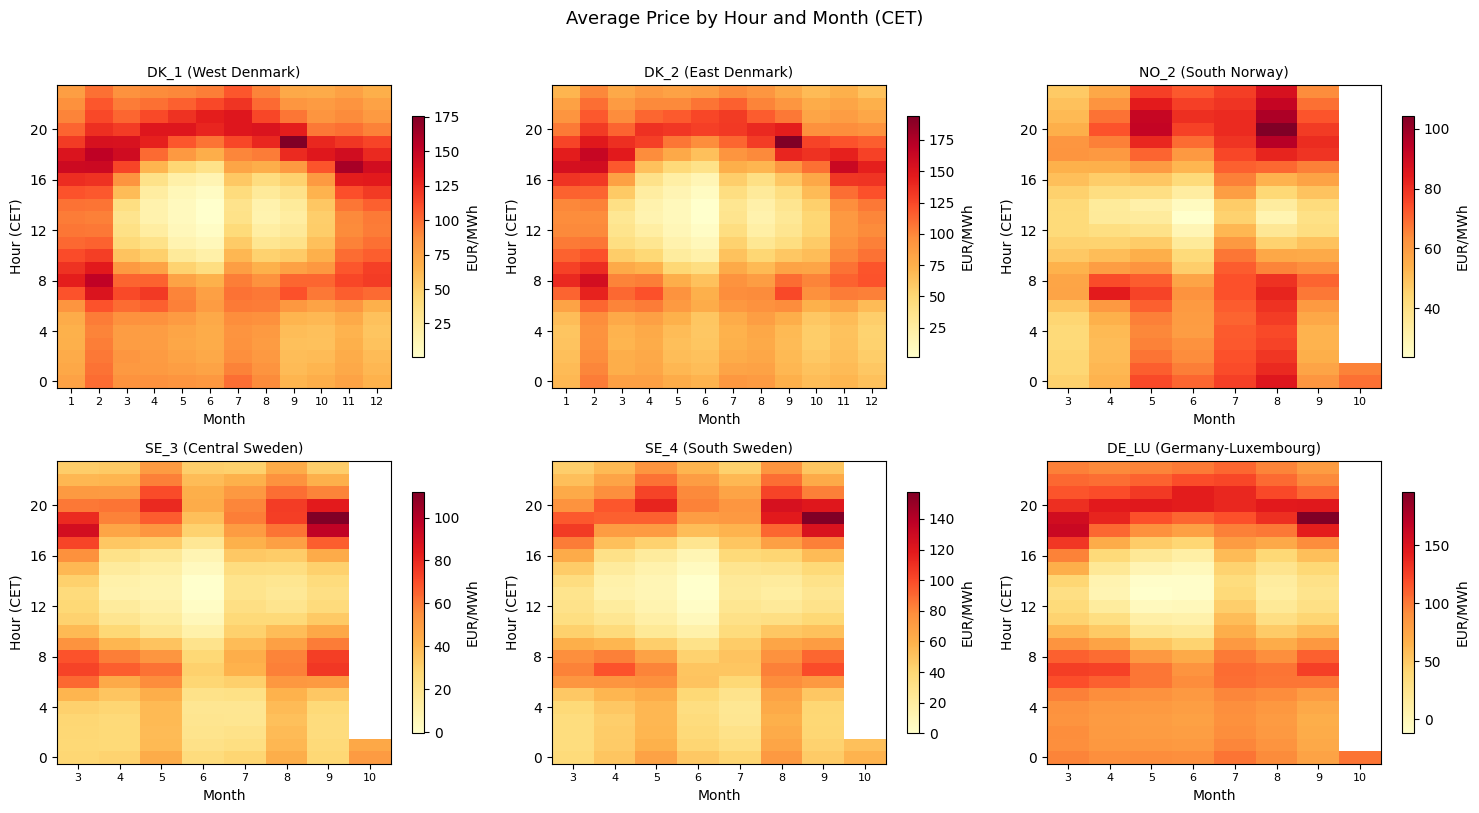

In [9]:
zones_with_data = [z for z in ZONES if z in all_prices.columns]
n_zones = len(zones_with_data)

if n_zones > 0:
    ncols = 3
    nrows = (n_zones + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten()

    for i, zone in enumerate(zones_with_data):
        ax = axes_flat[i]
        series = all_prices[zone].dropna()
        cet_idx = series.index.tz_convert("Europe/Copenhagen")

        pivot_data = pd.DataFrame({
            "hour": cet_idx.hour,
            "month": cet_idx.month,
            "price": series.values,
        })
        heatmap = pivot_data.groupby(["hour", "month"])["price"].mean().unstack(fill_value=np.nan)

        im = ax.imshow(
            heatmap.values, aspect="auto", cmap="YlOrRd",
            origin="lower", interpolation="nearest",
        )
        ax.set_title(f"{zone} ({ZONE_LABELS.get(zone, '')})", fontsize=10)
        ax.set_ylabel("Hour (CET)")
        ax.set_xlabel("Month")
        ax.set_yticks(range(0, 24, 4))
        ax.set_yticklabels(range(0, 24, 4))
        if heatmap.shape[1] > 0:
            ax.set_xticks(range(heatmap.shape[1]))
            ax.set_xticklabels(heatmap.columns, fontsize=8)
        plt.colorbar(im, ax=ax, label="EUR/MWh", shrink=0.8)

    # Hide unused subplots
    for j in range(n_zones, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle("Average Price by Hour and Month (CET)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No zone price data available for heatmap.")

## Summary

- **DK1** is the most interconnected Danish zone: 2,500 MW to Germany (AC lines),
  1,700 MW to Norway (Skagerrak cables), 740 MW to Sweden (SE3), and 600 MW to
  DK2 (Great Belt link).
- **DK2** connects to Germany via the 600 MW Kontek cable, and to SE4 with 1,700 MW.
- High correlation at lag 0 indicates uncongested interconnectors; decay with lag
  reveals how quickly price signals propagate across zones.
- Price spreads directly measure congestion rent -- persistent non-zero spreads
  indicate structural transmission bottlenecks.
- Heatmaps show that morning and evening peaks are common across all zones, with
  seasonal modulation driven by heating demand (winter) and solar availability (summer).